In [54]:
import pandas as pd
from pathlib import Path


folder = Path(".").resolve().parent.parent / "experiments" / "protein" / "hyper"


nn_names = ["le", "moe"]
data: dict[str, pd.DataFrame] = dict()

for run in folder.iterdir():

    if not run.is_dir():
        continue

    name = run.name.split("_")[2]

    if name not in data:
        data[name] = []

    df = pd.read_csv(run / f"{name}.csv")
    data[name].append(df)


corrective_RMSE_factor = 1
data = {name: pd.concat(dfs) for name, dfs in data.items()}

In [55]:
for name, df in data.items():
    print(name, df.shape[0])

lgbm 1800
rf 3582
moe 778
le 436


In [56]:
assert (data["le"]["best_rmse_results"] <= data["le"]["rmse_results"]).all()
assert (data["moe"]["best_rmse_results"] <= data["moe"]["rmse_results"]).all()

In [60]:
corrective_RMSE_factor

6.112627029418945

### Correct not denormed nn adapter

In [57]:
from liquid.train import load_protein

dataset, _ = load_protein()
corrective_RMSE_factor = dataset.tensors[1].std().item()

def correct(rmse: pd.Series, T: float=0.75):
    correct_mask = rmse < T
    rmse = rmse.copy()
    rmse[correct_mask] = rmse[correct_mask] * corrective_RMSE_factor
    return rmse

data["le"]["best_rmse_results"] = correct(data["le"]["best_rmse_results"])
data["le"]["rmse_results"] = correct(data["le"]["rmse_results"])
data["moe"]["rmse_results"] = correct(data["moe"]["rmse_results"])
data["moe"]["best_rmse_results"] = correct(data["moe"]["best_rmse_results"])

### Pure rmse look

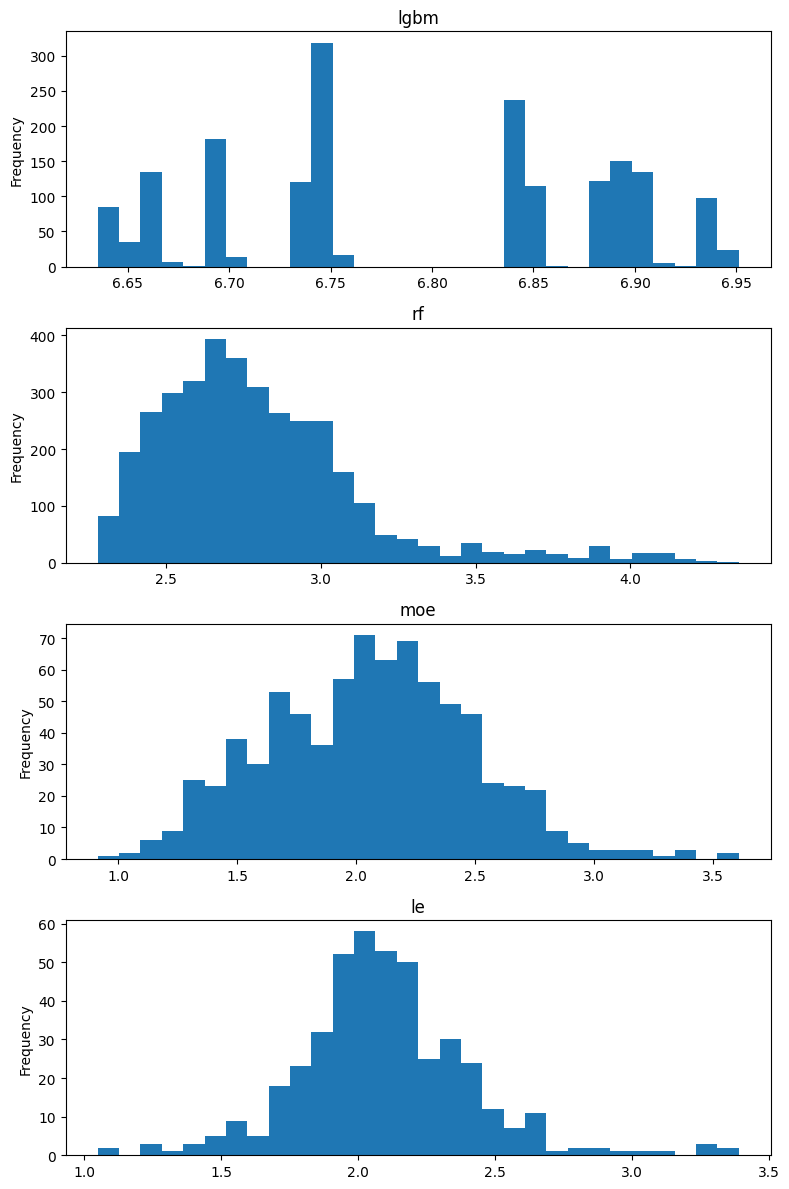

In [59]:
from matplotlib import pyplot as plt

fig, axs = plt.subplots(len(data), 1, figsize=(8, 3 * len(data)))

for (name, df), ax in zip(data.items(), axs):
    metric_name = "best_rmse_results" if name in nn_names else "rmse_results"
    metric = df[metric_name]

    metric.plot.hist(bins=30, ax=ax)
    ax.set_title(name)


fig.tight_layout()


### Nbytes over RMSE

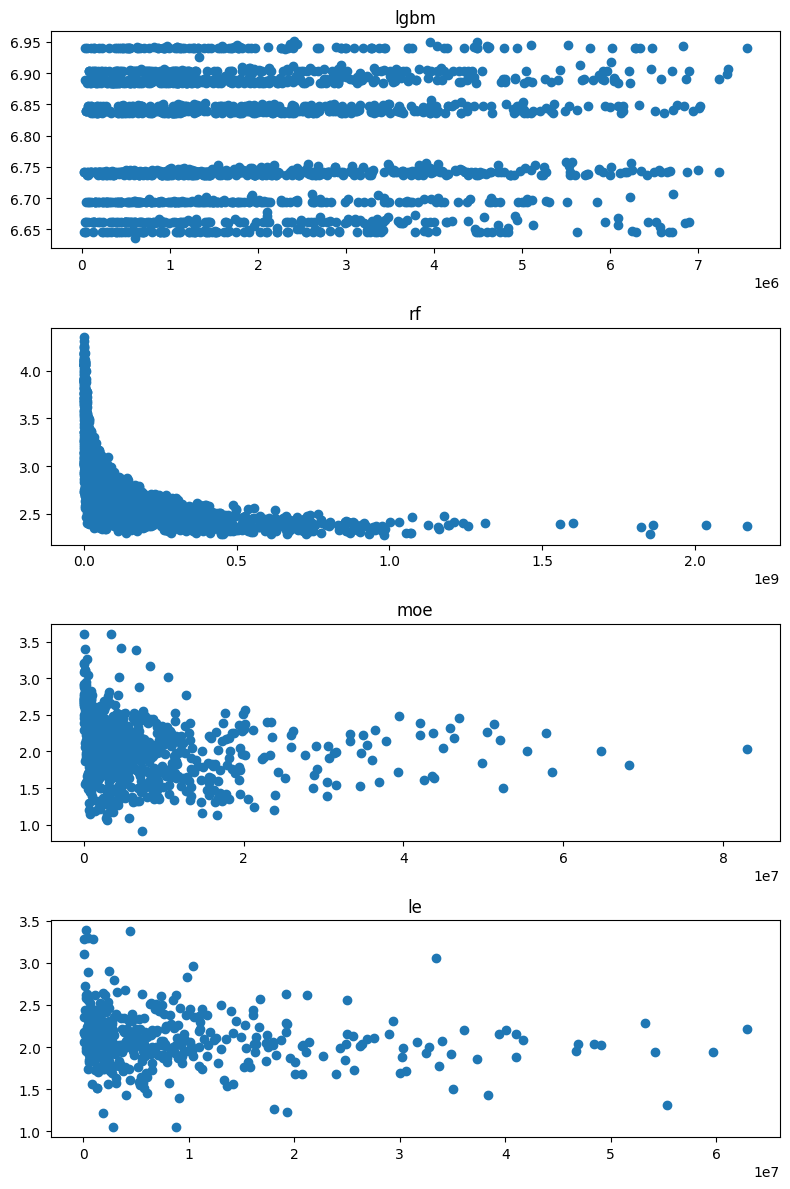

In [66]:
import numpy as np

fig, axs = plt.subplots(len(data), 1, figsize=(8, 3 * len(data)))

for (name, df), ax in zip(data.items(), axs):

    metric_name = "best_rmse_results" if name in nn_names else "rmse_results"

    x = df["nbytes_results"].to_numpy()
    y = df[metric_name].to_numpy()

    ax.scatter(x, y)
    ax.set_title(name)


fig.tight_layout()

### Shapley value

In [273]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

import shapiq


def get_inputs(df: pd.DataFrame) -> pd.DataFrame:

    exclude = [
    "batch_size",
    "name",
    "verbose",
    "n_input",
    "n_output",
    "solver"
    ] + df.columns[df.columns.str.contains("results")].tolist()

    exclude.remove("train_time_results")
    exclude.remove("nbytes_results")

    return df.drop(columns=exclude, errors="ignore")

def to_numpy(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:

    df = df.copy()

    ok_columns = df.select_dtypes(include='number').columns
    bad_columns = df.columns[~df.columns.isin(ok_columns)]

    if bad_columns.size == 0:
        return df.to_numpy(), df.columns.to_numpy()

    print(bad_columns.tolist(), "will be converted to categorical value")

    for col in bad_columns:
        df[col] = df[col].astype("category").cat.codes


    return df.to_numpy(), df.columns.to_numpy()


def check_for_too_large_errors(X: np.ndarray, y: np.ndarray, model: RandomForestRegressor, tsr: float = 0.05):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=tsr)
    model.fit(X_train, y_train)
    yhat = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, yhat)
    print("Surrogate model validation rmse", rmse)



def explain_model_metric(df: pd.DataFrame, metric: str, tree: bool=False):

    surrogate = RandomForestRegressor(n_estimators=50, warm_start=False)

    X, feature_names = to_numpy(get_inputs(df))
    y = df[metric].to_numpy()

    check_for_too_large_errors(X, y, surrogate)

    surrogate.fit(X, y)

    if not tree:

        explainer = shapiq.TabularExplainer(
            model=surrogate,
            data=X,
            index="k-SII",
            approximator="svarm",
            max_order=2
        )

        explanations = explainer.explain_X(
            X,
            budget=256,
            verbose=True,
            n_jobs=4
        )
    else:

        explainer = shapiq.TreeExplainer(
            model=surrogate,
            data=X,
            index="k-SII",
            max_order=2
        )

        explanations = explainer.explain_X(
            X,
            verbose=True,
            n_jobs=4
        )

    return explanations, feature_names

In [269]:
surrogate = RandomForestRegressor(n_estimators=50, warm_start=False)

test = "le"

X, feature_names = to_numpy(get_inputs(data[test]))
y = data[test]["best_rmse_results"].to_numpy()

surrogate.fit(X, y)

explainer = shapiq.TreeExplainer(
    model=surrogate,
    data=X,
    index="k-SII",
    max_order=2
)

explainer.explain(X[11])

InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=None,
    n_players=16, baseline_value=2.095651470060269
)

In [271]:
data[test].shape

(436, 34)

In [279]:

explain_model = "le"
explanations, feature_names = explain_model_metric(data[explain_model], "best_rmse_results", tree=True)

Surrogate model validation rmse 0.26070192798553093


Explaining:   6%|▌         | 44/778 [41:00<11:24:01, 55.91s/it]


In [280]:
from shapiq.interaction_values import aggregate_interaction_values

global_explanation = aggregate_interaction_values(explanations, aggregation="mean")

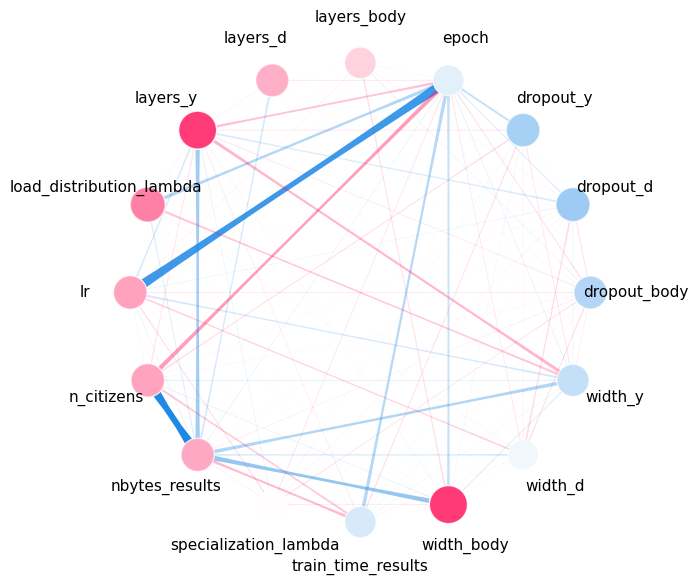

In [281]:
global_explanation.plot_network(feature_names=feature_names)

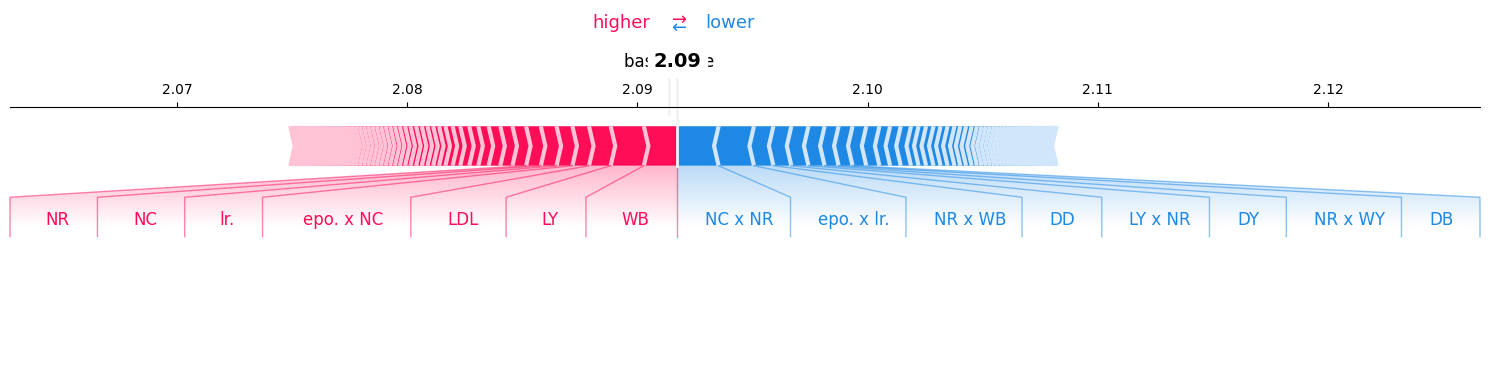

In [282]:
global_explanation.plot_force(contribution_threshold=0.02, feature_names=feature_names, abbreviate=True)

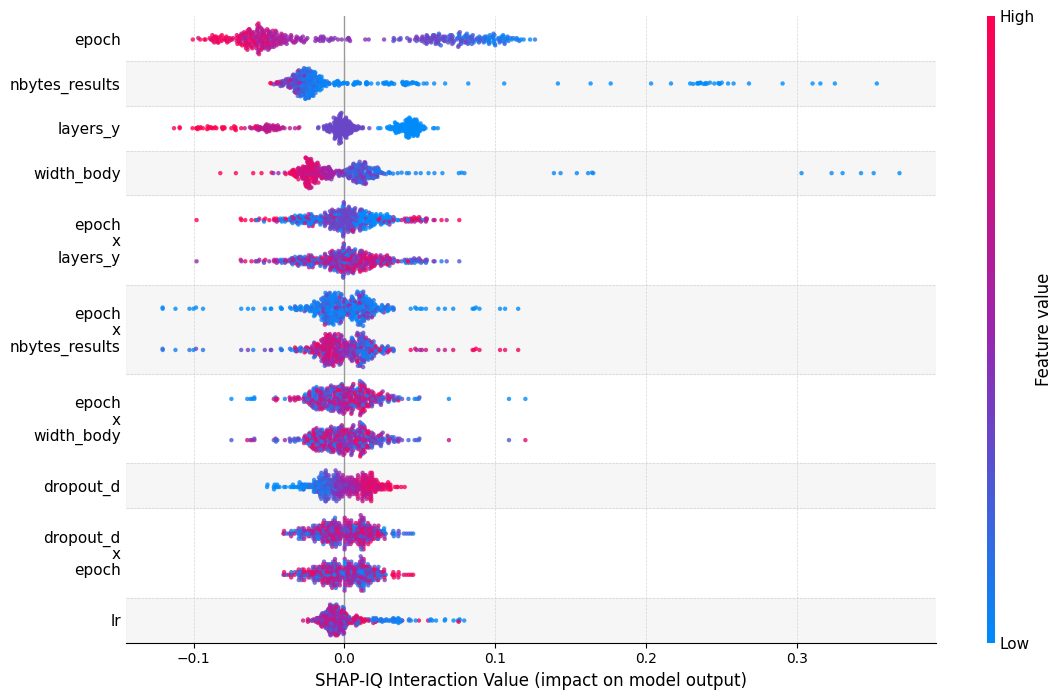

In [283]:
shapiq.beeswarm_plot(explanations, to_numpy(get_inputs(data[explain_model]))[0], feature_names=feature_names, abbreviate=False)

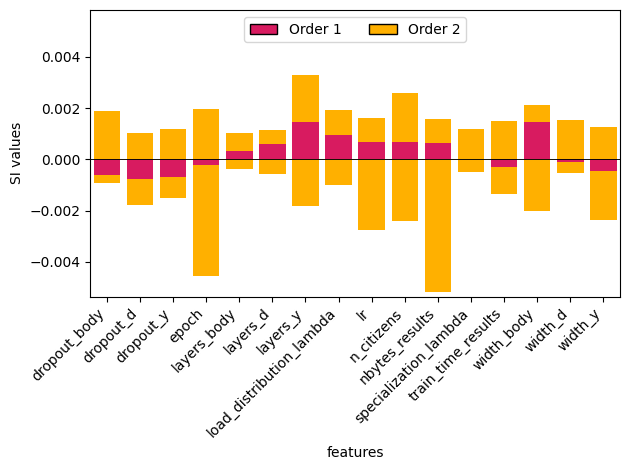

In [285]:
global_explanation.plot_stacked_bar(feature_names=feature_names)

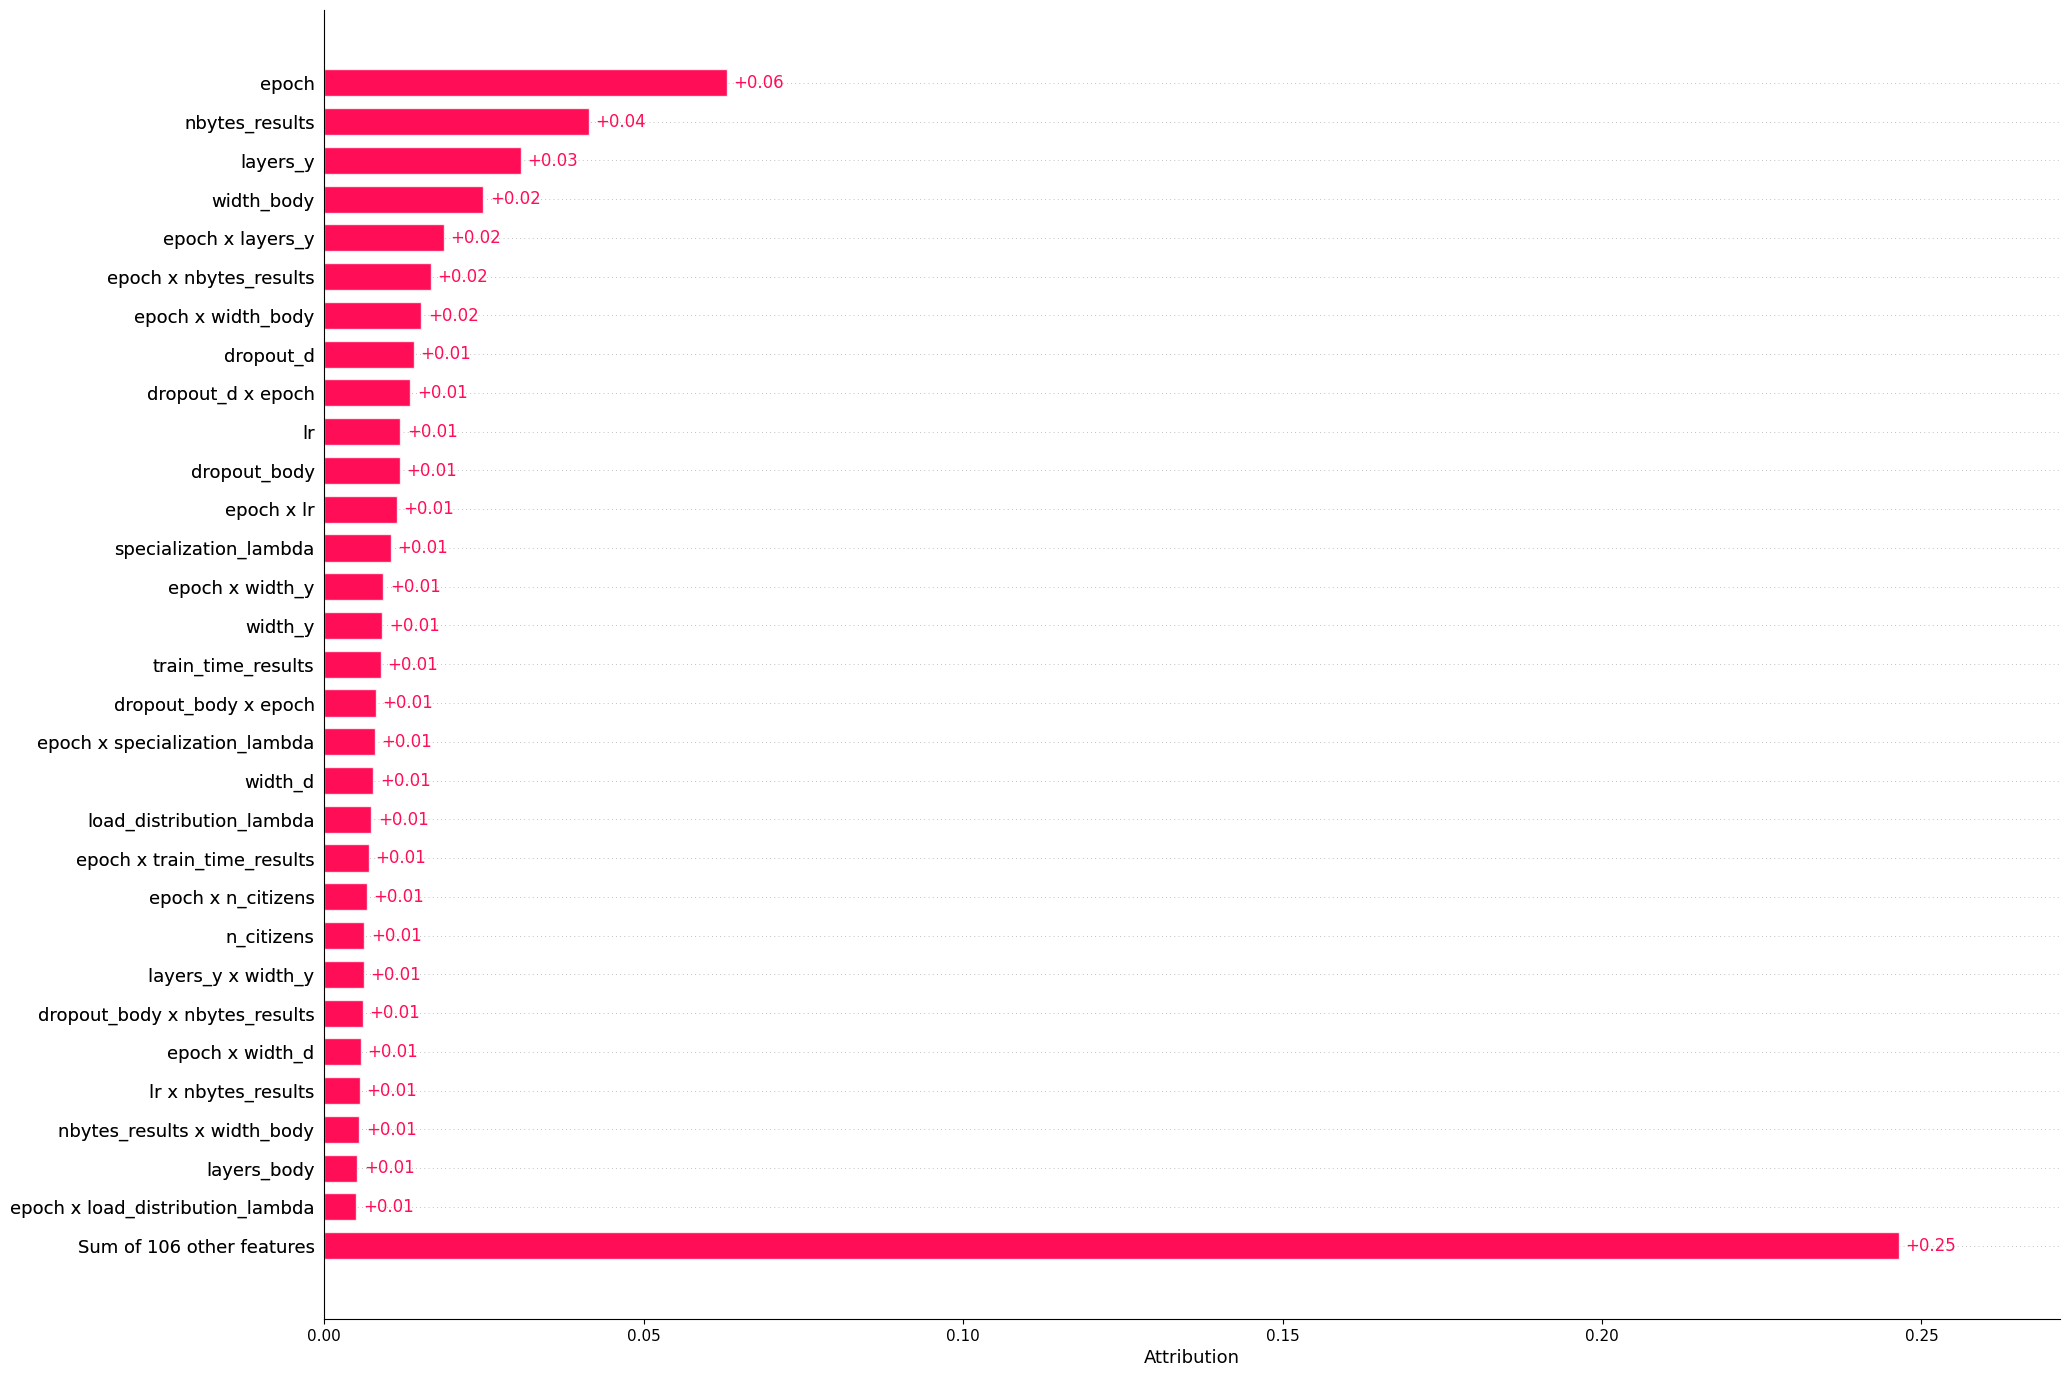

In [286]:
shapiq.plot.bar_plot(explanations, feature_names=feature_names, abbreviate=False, show=True, max_display=30)

In [211]:
get_inputs(data["rf"]).columns.size

8

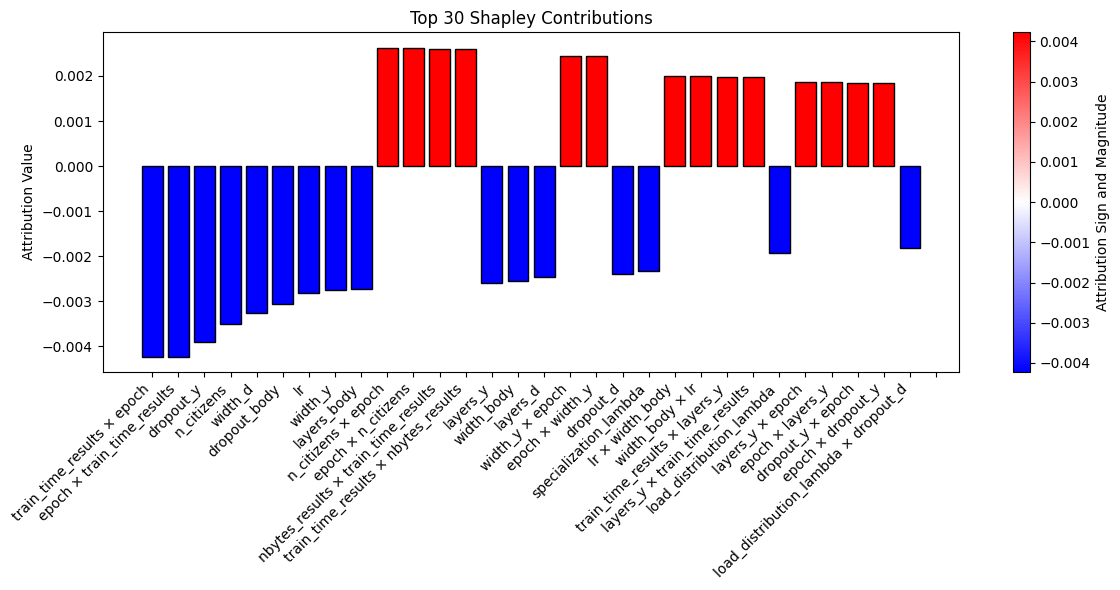

In [207]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def plot_top_shap_contributions(*shap_arrays, feature_names: np.ndarray, top: int = 10, plot_rest: bool = False):
    N = feature_names.shape[0]
    flat_entries = []
    labels = []

    for arr in shap_arrays:
        it = np.ndindex(arr.shape)
        for idx in it:
            val = arr[idx]
            label = tuple(feature_names[i] for i in idx)
            flat_entries.append(val)
            labels.append(label)

    flat_entries = np.array(flat_entries)
    magnitudes = np.abs(flat_entries)
    sorted_indices = np.argsort(-magnitudes)
    top_indices = sorted_indices[:top]
    rest_indices = sorted_indices[top:]

    top_vals = flat_entries[top_indices]
    top_labels = [labels[i] for i in top_indices]
    rest_sum = np.sum(np.abs(flat_entries[rest_indices]))

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['red' if v >= 0 else 'blue' for v in top_vals]
    ax.bar(range(top), top_vals, color=colors, edgecolor='black')

    if plot_rest:
        vmax = max(top_vals.max(), rest_sum)
        ax.bar(top, rest_sum, color='gray', edgecolor='black')
    else:
        vmax = top_vals.max()


    vmin = top_vals.min()
    if (-vmin) > vmax:
        vmax = -vmin
    else:
        vmin = -vmax

    xticks = [' × '.join(lbl) for lbl in top_labels] + (['Rest'] if plot_rest else [""])
    ax.set_xticks(range(top + 1))
    ax.set_xticklabels(xticks, rotation=45, ha='right')
    ax.set_ylabel("Attribution Value")
    ax.set_title(f"Top {top} Shapley Contributions")



    norm = Normalize(vmin=vmin, vmax=vmax)
    sm = ScalarMappable(cmap='bwr', norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Attribution Sign and Magnitude')

    plt.tight_layout()
    plt.show()

plot_top_shap_contributions(
    global_explanation.get_n_order_values(1),
    global_explanation.get_n_order_values(2),
    global_explanation.get_n_order_values(3),
    top=30,
    feature_names=feature_names,
    plot_rest=False
)


In [212]:
global_explanation.n_players

16

In [103]:
data["rf"].select_dtypes("object")

,name
0,protein
1,protein
2,protein
3,protein
4,protein
...,...
571,protein
572,protein
573,protein
574,protein


In [223]:
def check(df: pd.DataFrame, metric: str):
    surrogate = RandomForestRegressor(n_estimators=100, warm_start=False)

    X, feature_names = to_numpy(get_inputs(df))
    y = df[metric].to_numpy()

    check_for_too_large_errors(X, y, surrogate, tsr=0.2)

    surrogate.fit(X, y)

    yhat = surrogate.predict(X)
    print(yhat.std())

check(data["le"], "best_rmse_results")

Surrogate model validation rmse 0.24763220967020225
0.22642694530914909
